Castro Supermarket operates supermarket branches in Lagos, Abuja and Port Harcourt. 
The company has collected three months of transaction data and wants to use the data to understand 
1. Customer Behaviour
2. Sales performance
3. Payment preferences
4. Branch performance

# Data Exploration

In [364]:
import numpy as np
import pandas as pd

# Data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sb

%matplotlib inline

In [365]:
lagos_df = pd.read_excel("Lagos_Branch.xlsx", sheet_name='Lagos_Branch')
abuja_df = pd.read_excel("Abuja_Branch.xlsx", sheet_name='Abuja_Branch')
port_harcourt_df = pd.read_excel("Port_Harcourt_Branch.xlsx", sheet_name='Port_Harcourt_Branch')

combined_df = pd.concat([lagos_df, abuja_df, port_harcourt_df], ignore_index=True)
print(combined_df)

      Invoice ID Branch           City Customer type  Gender  \
0    750-67-8428      A          Lagos        Member  Female   
1    631-41-3108      A          Lagos        Normal    Male   
2    123-19-1176      A          Lagos        Member    Male   
3    373-73-7910      A          Lagos        Normal    Male   
4    355-53-5943      A          Lagos        Member  Female   
..           ...    ...            ...           ...     ...   
995  148-41-7930      C  Port Harcourt        Normal    Male   
996  189-40-5216      C  Port Harcourt        Normal    Male   
997  267-62-7380      C  Port Harcourt        Member    Male   
998  652-49-6720      C  Port Harcourt        Member  Female   
999  233-67-5758      C  Port Harcourt        Normal    Male   

               Product line  Unit price  Quantity    Tax 5%      Total  \
0         Health and beauty     26888.4         7   9410.94  197629.74   
1        Home and lifestyle     16678.8         7   5837.58  122589.18   
2        

In [254]:
# first 5 records

combined_df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Lagos,Member,Female,Health and beauty,26888.4,7,9410.94,197629.74,2019-01-05,13:08:00,Epay,188218.8,4.761905,9410.94,9.1
1,631-41-3108,A,Lagos,Normal,Male,Home and lifestyle,16678.8,7,5837.58,122589.18,2019-03-03,13:23:00,Card,116751.6,4.761905,5837.58,7.4
2,123-19-1176,A,Lagos,Member,Male,Health and beauty,20959.2,8,8383.68,176057.28,2019-01-27,20:33:00,Epay,167673.6,4.761905,8383.68,8.4
3,373-73-7910,A,Lagos,Normal,Male,Sports and travel,31071.6,7,10875.06,228376.26,2019-02-08,10:37:00,Epay,217501.2,4.761905,10875.06,5.3
4,355-53-5943,A,Lagos,Member,Female,Electronic accessories,24782.4,6,7434.72,156129.12,2019-02-25,14:36:00,Epay,148694.4,4.761905,7434.72,5.8


In [255]:
# last 5 records

combined_df.tail()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
995,148-41-7930,C,Port Harcourt,Normal,Male,Health and beauty,35985.6,7,12594.96,264494.16,2019-01-23,10:33:00,Cash,251899.2,4.761905,12594.96,6.1
996,189-40-5216,C,Port Harcourt,Normal,Male,Electronic accessories,34693.2,7,12142.62,254995.02,2019-01-09,11:40:00,Cash,242852.4,4.761905,12142.62,6.0
997,267-62-7380,C,Port Harcourt,Member,Male,Electronic accessories,29642.4,10,14821.20,311245.20,2019-03-29,19:12:00,Epay,296424.0,4.761905,14821.20,4.3
998,652-49-6720,C,Port Harcourt,Member,Female,Electronic accessories,21942.0,1,1097.10,23039.10,2019-02-18,11:40:00,Epay,21942.0,4.761905,1097.10,5.9
999,233-67-5758,C,Port Harcourt,Normal,Male,Health and beauty,14526.0,1,726.30,15252.30,2019-01-29,13:46:00,Epay,14526.0,4.761905,726.30,6.2


In [256]:
# Number of rows and columns

combined_df.shape

(1000, 17)

In [366]:
# Checking for null values

combined_df.isnull().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

In [258]:
# Checking for duplicates

combined_df.duplicated().sum()

np.int64(0)

In [259]:
# some descriptive statistic( include info and describe)

combined_df.info

<bound method DataFrame.info of       Invoice ID Branch           City Customer type  Gender  \
0    750-67-8428      A          Lagos        Member  Female   
1    631-41-3108      A          Lagos        Normal    Male   
2    123-19-1176      A          Lagos        Member    Male   
3    373-73-7910      A          Lagos        Normal    Male   
4    355-53-5943      A          Lagos        Member  Female   
..           ...    ...            ...           ...     ...   
995  148-41-7930      C  Port Harcourt        Normal    Male   
996  189-40-5216      C  Port Harcourt        Normal    Male   
997  267-62-7380      C  Port Harcourt        Member    Male   
998  652-49-6720      C  Port Harcourt        Member  Female   
999  233-67-5758      C  Port Harcourt        Normal    Male   

               Product line  Unit price  Quantity    Tax 5%      Total  \
0         Health and beauty     26888.4         7   9410.94  197629.74   
1        Home and lifestyle     16678.8         7  

In [260]:
combined_df.describe()

,Unit price,Quantity,Tax 5%,Total,Date,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000.000000,1.000000e+03,1000.000000,1000.00000
mean,20041.966800,5.510000,5536.572840,116268.029640,2019-02-14 00:05:45.600000,110731.456800,4.761905e+00,5536.572840,6.97270
min,3628.800000,1.000000,183.060000,3844.260000,2019-01-01 00:00:00,3661.200000,4.761905e+00,183.060000,4.00000
25%,11835.000000,3.000000,2132.955000,44792.055000,2019-01-24 00:00:00,42659.100000,4.761905e+00,2132.955000,5.50000
50%,19882.800000,5.000000,4351.680000,91385.280000,2019-02-13 00:00:00,87033.600000,4.761905e+00,4351.680000,7.00000
75%,28056.600000,8.000000,8080.290000,169686.090000,2019-03-08 00:00:00,161605.800000,4.761905e+00,8080.290000,8.50000
max,35985.600000,10.000000,17874.000000,375354.000000,2019-03-30 00:00:00,357480.000000,4.761905e+00,17874.000000,10.00000
std,9538.066205,2.923431,4215.177173,88518.720636,NaN,84303.543463,7.197845e-14,4215.177173,1.71858


## Data cleaning and preparation

In [367]:
# Inspecting the datatype for each column
# Although, after inpecting, found out all data type for each column are correct

combined_df.dtypes

Invoice ID                         object
Branch                             object
City                               object
Customer type                      object
Gender                             object
Product line                       object
Unit price                        float64
Quantity                            int64
Tax 5%                            float64
Total                             float64
Date                       datetime64[ns]
Time                               object
Payment                            object
cogs                              float64
gross margin percentage           float64
gross income                      float64
Rating                            float64
dtype: object

In [368]:
# To convert the date column to datetime format

combined_df["DateTime"] = pd.to_datetime(
    combined_df["Date"].astype(str) + " " + combined_df["Time"].astype(str)
)

# Now to create Month column, Day of the week column and Hour columns

combined_df["Month"] = combined_df["DateTime"].dt.month_name()
combined_df["Month_Number"] = combined_df["DateTime"].dt.month
combined_df["Day_of_Week"] = combined_df["DateTime"].dt.dayofweek
combined_df["Day_Type"] = np.where(
    combined_df["Day_of_Week"] >= 5, "Weekend", "Weekday"
)
combined_df["Hour"] = combined_df["DateTime"].dt.hour

In [369]:
# To check the result of what was done 

combined_df[["Date", "Time", "DateTime", "Month", "Month_Number", "Day_of_Week", "Hour"]].head()

,Date,Time,DateTime,Month,Month_Number,Day_of_Week,Hour
0,2019-01-05,13:08:00,2019-01-05 13:08:00,January,1,5,13
1,2019-03-03,13:23:00,2019-03-03 13:23:00,March,3,6,13
2,2019-01-27,20:33:00,2019-01-27 20:33:00,January,1,6,20
3,2019-02-08,10:37:00,2019-02-08 10:37:00,February,2,4,10
4,2019-02-25,14:36:00,2019-02-25 14:36:00,February,2,0,14


In [264]:
# To check for duplicate transactions, i am using the Invoice ID

# However, there are no duplicated transactions found

combined_df["Invoice ID"].duplicated().sum()

np.int64(0)

In [370]:
# I decided to change the values in branch column from A,B,C to lagos, abuja, port harcourt respectively

combined_df['Branch'] = combined_df['Branch'].replace({
    'A': 'lagos',
    'B': 'abuja',
    'C': 'port harcourt'
})

## Data Exploration

In [291]:
# firstly i need to confirm what the name of branches are

combined_df["Branch"].unique()

array(['lagos', 'abuja', 'port harcourt'], dtype=object)

In [371]:
## functions to generate plots

# pie plot
def plot_pie(data, labels, title):
    plt.pie(data, labels=labels, autopct='%1.1f%%', colors=['olivedrab', 'rosybrown', 'gray', 'saddlebrown'])
    plt.title(f'Pie plot of {title}')
    sb.despine()
    plt.savefig(f'{title}.png')
    plt.show()

# bar plot
def generate_bar_plot(x, y, xlabel, ylabel):
    plt.bar(x, y, color='grey', edgecolor='black')
    plt.title(f'Plot of {ylabel} against {xlabel}')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    sb.despine()
    plt.savefig(f'Plot of {ylabel} against {xlabel}.png')
    plt.show()

# line plot

def generate_line_plot(x, y, data, hue=None):
    sb.lineplot(x=x, y=y,data=data, markers=True, dashes=False, estimator=sum, color='grey', hue=hue)
    plt.title(f'Plot of {y} as {x} changes')
    plt.xlabel(x)
    plt.ylabel(y)
    sb.despine()
    plt.savefig(f'Plot of {y} as {x} changes.png')
    plt.show()

# Exploratory data analysis

In [372]:
# To compare total sales across Lagos, Abuja and Port Harcourt branches


Branch_sales = combined_df.groupby("Branch", as_index=False)[["Total"]].sum()
print(Branch_sales)

          Branch        Total
0          abuja  38231161.92
1          lagos  38232133.38
2  port harcourt  39804734.34


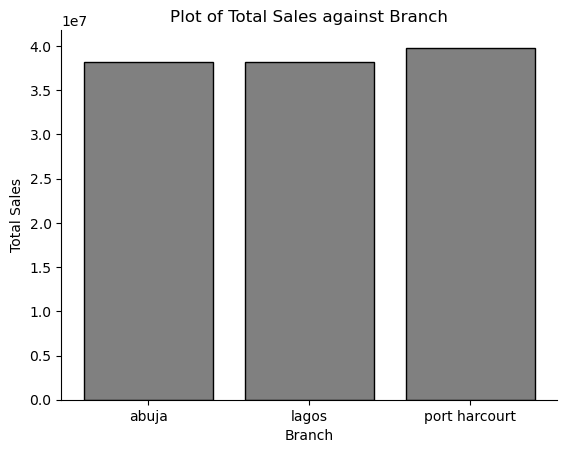

In [269]:
generate_bar_plot(Branch_sales['Branch'],Branch_sales['Total'], 'Branch', 'Total Sales')

The results showed Port Harcourt has the highest number of sales among the 3 branches 

While Abuja had the lowest number of sales

In [294]:
# Determine which branch generates the highest gross income

Branch_income = combined_df.groupby("Branch")["gross income"].sum()
print(Branch_income)

Branch
abuja            1820531.52
lagos            1820577.78
port harcourt    1895463.54
Name: gross income, dtype: float64


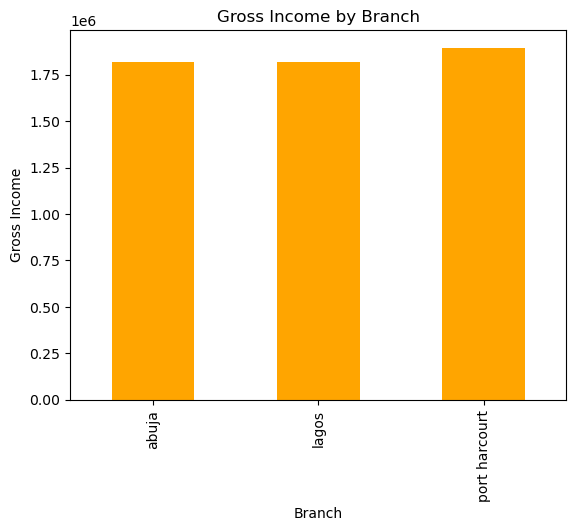

In [295]:
Branch_income.plot(kind='bar', color='orange')
plt.title('Gross Income by Branch')
plt.ylabel('Gross Income')
plt.xlabel('Branch')

plt.show()

 The result showed that port harcourt branch generated the highest gross income among the branches

In [300]:
# Analyse sales performance by MONTH
monthly_branch_sales = (
    combined_df.groupby(["Month", "Branch"])["Total"]
    .sum()
)
print(monthly_branch_sales)

Month     Branch       
February  abuja            12392737.56
          lagos            10749643.38
          port harcourt    11856593.70
January   abuja            13383381.06
          lagos            13925206.26
          port harcourt    14556485.16
March     abuja            12455043.30
          lagos            13557283.74
          port harcourt    13391655.48
Name: Total, dtype: float64


# Peak Performance Month:
January recorded the highest combined revenue generation across all regional locations, accumulating a monthly total of 41,865,072.48.
# Lowest Performance Month: 
February experienced a noticeable dip across all territories, dropping to a combined performance of 34,998,694.64.
# Top Regional Contributor: 
The Port Harcourt branch brought in the highest overall total volume across the entire quarter, reaching 39,804,734.34. This edge was primarily driven by its outstanding performance in January.
# Competitive Balance: 
Lagos (38,232,133.38) and Abuja (38,231,161.92) performed almost identically over the three months, finishing with a separation of less than 1,000 units.
# Quarterly Grand Total: 
The total collective metric across all branches and months combines to a sum of 116,268,029.64.

In [301]:
# Identify the best-performing product lines by sales and quantity

product_performance = (
    combined_df.groupby("Product line")
    .agg(
        Total_Sales=("Total", "sum"),
        Total_Quantity=("Quantity", "sum")
    )
)
print(product_performance)

                        Total_Sales  Total_Quantity
Product line                                       
Electronic accessories  19561511.34             971
Fashion accessories     19550122.20             902
Food and beverages      20212143.84             952
Health and beauty       17709746.04             854
Home and lifestyle      19390288.68             911
Sports and travel       19844217.54             920


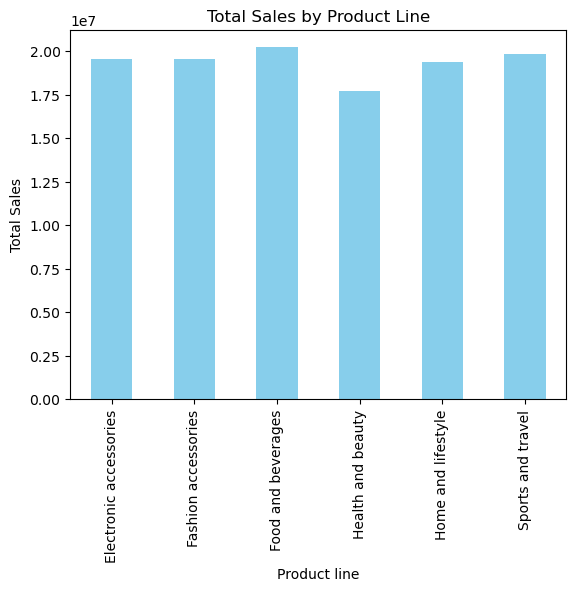

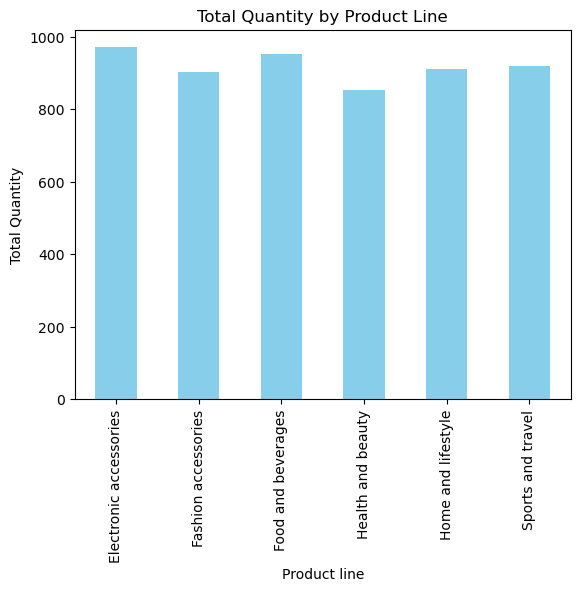

In [302]:
product_performance['Total_Sales'].plot(kind='bar', color='skyblue')
plt.title('Total Sales by Product Line')
plt.ylabel('Total Sales')
plt.xlabel('Product line')

plt.show()

product_performance['Total_Quantity'].plot(kind='bar', color='skyblue')
plt.title('Total Quantity by Product Line')
plt.ylabel('Total Quantity')
plt.xlabel('Product line')

plt.show()

# Top Revenue Generator: Food and beverages
Brings in the highest total revenue (20.212M), driven by both high volume (952 quantities sold) and strong pricing.
# Volume Leader: Electronic accessories 
Sold the most quantity overall (971), though it ranks 3rd in total revenue due to having a slightly lower average item value(20,145.33).
# Lowest Performer: Health and beauty 
Lags behind in both total revenue (17.71M) and sales volume (854 units).

In [275]:
# Compare sales generated by members and normal customers

sales_by_customer = combined_df.groupby("Customer type")["Total"].sum()
print(sales_by_customer)

Customer type
Member    59120439.84
Normal    57147589.80
Name: Total, dtype: float64


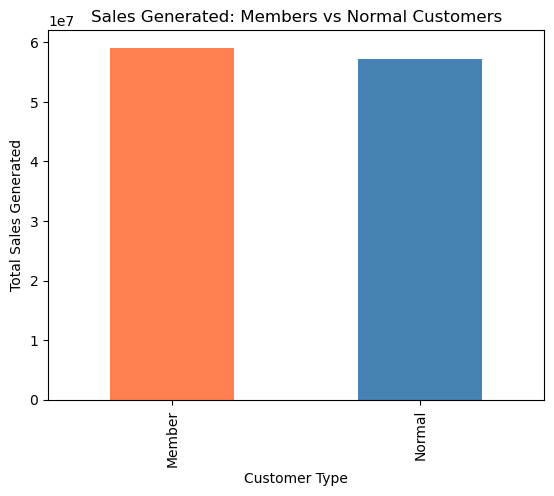

In [303]:
sales_by_customer.plot(kind='bar', color=['coral', 'steelblue'])
plt.title('Sales Generated: Members vs Normal Customers')
plt.ylabel('Total Sales Generated')
plt.xlabel('Customer Type')
plt.show()

# Member accounts :
Generated a total of 59,120,439.84 in sales.
# Normal accounts:
Generated a total of 57,147,589.80 in sales.
# Key Insights:
Customers with a "Member" status generated more revenue than "Normal" customers.
The difference between the two categories is relatively small. 
Member sales exceed non-member sales by 1,972,850.04, which is only about a 3.45% increase.
The data suggests that while membership programs are driving the highest portion of sales, normal customers still make up a massive, nearly equal share of the total revenue.

In [304]:
# Analyse purchasing behaviour by gender

sales_by_gender = combined_df.groupby('Gender')['Total'].sum()
print(sales_by_gender)

Gender
Female    60437853.00
Male      55830176.64
Name: Total, dtype: float64


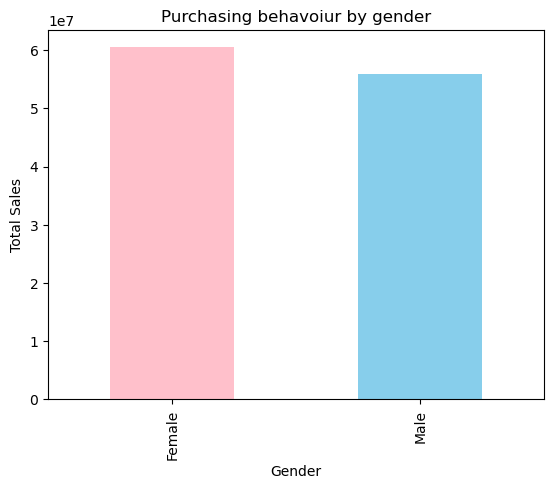

In [305]:
sales_by_gender.plot(kind='bar', color=['pink', 'skyblue'])
plt.title('Purchasing behavoiur by gender')
plt.ylabel('Total Sales')
plt.xlabel('Gender')
plt.show()

Female sales drive the highest revenue, totaling 60,437,853.00.
Male sales follow closely behind, totaling 55,830,176.44.
Female customers spent more than male customers by exactly 4,607,676.56 in total sales.


 Key Insights  
While both demographics contribute significantly (both are in the 50M+ range), female consumers represent the largest revenue-generating segment.
The gap between the two groups is relatively small (roughly an 8% difference). This indicates that the product or service holds strong, broad appeal across both major gender demographics rather than being strictly niche.

In [306]:
# Determine the most commonly used payment method overall and by branch

combined_df = combined_df.groupby('Payment', as_index=False)['Invoice ID'].count()
combined_df

,Payment,Invoice ID
0,Card,311
1,Cash,344
2,Epay,345


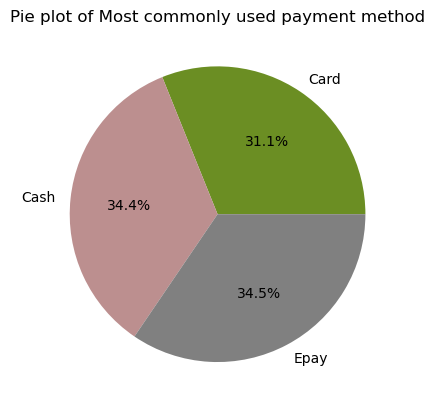

In [307]:
plot_pie(combined_df['Invoice ID'], combined_df['Payment'], 'Most commonly used payment method')

# The Most Common Payment Method: 
Epay is the most frequently used option overall, accounting for 345 transactions (34.50%).
There is a minimal difference between Epay and card preferences. Epay leads Cash by only a single invoice.
# The least used Payment Method
Traditional Card payments lag slightly behind the other methods, representing 311 transactions (31.10%).

The overall transaction distribution is remarkably uniform across all three methods. No single payment format dominantly controls the market share; each captures between 31% and 35% of customer preferences.

In [313]:
# Most commonly used payment method by branch

branch_payment = combined_df.groupby('Branch')['Payment'].value_counts()
print(branch_payment)

Branch  Payment
A       Epay       126
        Cash       110
        Card       104
B       Epay       113
        Cash       110
        Card       109
C       Cash       124
        Epay       106
        Card        98
Name: count, dtype: int64


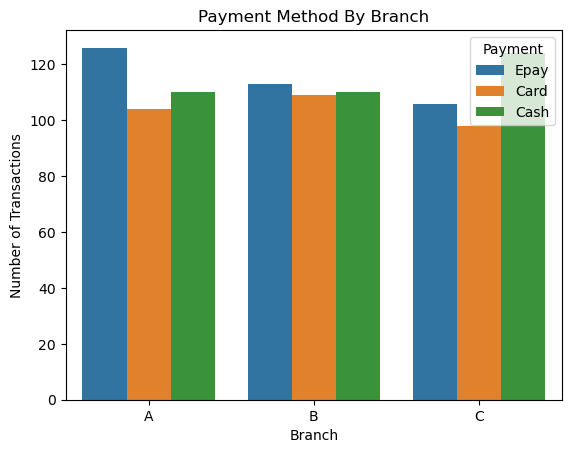

In [314]:
sb.countplot(data=combined_df, x='Branch', hue='Payment')
plt.title('Payment Method By Branch')
plt.xlabel('Branch')
plt.ylabel('Number of Transactions')
plt.show()

# Abuja Branch: 
Epay is the most popular payment method with 113 transactions, closely followed by Cash (110) and Card (109). The distribution here is highly balanced, meaning customers have no strong single preference.
# Lagos Branch: 
Epay is clearly dominant here with 126 transactions (the highest single count across all branches). Card is the least preferred method at 104.
# Port Harcourt Branch: 
Unlike the other two cities, Cash is the favorite choice with 124 transactions. Card is the least popular method here as well, falling below 100 transactions (98).

In [247]:
# Analyse Customer ratings and compare ratings across branches

rating_analysis = combined_df.groupby( 'Branch')['Rating'].describe()
print(rating_analysis)

               count      mean       std  min  25%  50%  75%   max
Branch                                                            
abuja          332.0  6.818072  1.713719  4.0  5.3  6.7  8.2  10.0
lagos          340.0  7.027059  1.731345  4.0  5.6  7.1  8.5  10.0
port harcourt  328.0  7.072866  1.704526  4.0  5.6  7.1  8.5  10.0


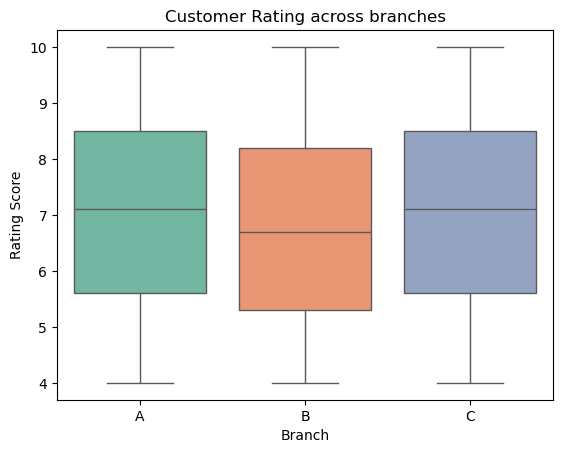

In [315]:
sb.boxplot(data=combined_df, x='Branch', y='Rating', hue='Branch', palette='Set2', legend=False)

plt.title('Customer Rating across branches')
plt.xlabel('Branch')
plt.ylabel('Rating Score')
plt.show()

# Performance Leaders (Lagos & Port Harcourt):
Looking at the box plot, the horizontal lines inside the boxes (the medians) for Lagos and Port Harcourt sit higher up (around 7.1).
Their middle 50% blocks (the colored boxes) are positioned higher on the scale, showing that a significant portion of their customers leave higher rating scores.

# Underperforming Branch (Abuja):
Abuja’s median line is lower (6.7). The entire salmon pink box is shifted downwards relative to the other two, confirming that customers at the Abuja branch are generally less satisfied.

The height of all three boxes is nearly identical. This means the spread and variance of customer opinions are uniform across all locations; no single branch suffers from wildly unpredictable or erratic service compared to the others. 
Abuja simply has a consistently lower baseline of satisfaction.


In [320]:
# Identify the busiest shopping hours overall 

busiest_hours = combined_df['Hour'].value_counts()
print(busiest_hours)

Hour
19    113
13    103
15    102
10    101
18     93
11     90
12     89
14     83
16     77
20     75
17     74
Name: count, dtype: int64


In [327]:
# Identify the busiest shopping hours for each branch

busiest_hour_per_branch = combined_df.groupby(['Branch', 'Hour'])['Invoice ID'].count()
print(busiest_hour_per_branch)

Branch         Hour
abuja          10      26
               11      33
               12      25
               13      38
               14      30
               15      32
               16      17
               17      20
               18      35
               19      50
               20      26
lagos          10      38
               11      35
               12      33
               13      31
               14      25
               15      37
               16      32
               17      27
               18      33
               19      27
               20      22
port harcourt  10      37
               11      22
               12      31
               13      34
               14      28
               15      33
               16      28
               17      27
               18      25
               19      36
               20      27
Name: Invoice ID, dtype: int64


1. Based on the result above, Hour 19 (7:00 PM) is the busiest overall shopping hour, recording a peak of 113 transactions

2. The busiest shopping hour for each branch 

Abuja: Hour 19 (7:00 PM), recording a peak of 50 transactions

Lagos: Hour 10 (10:00 AM), recording a peak of 38 transactions

Port Harcourt: Hour 10 (10:00 AM), recording a peak of 37 transactions

In [329]:
# Investigate the relationship between Customer rating and Sales/Gross Income

corr = combined_df[['Rating', 'Total']].corr()
corr

,Rating,Total
Rating,1.000000,-0.036442
Total,-0.036442,1.000000


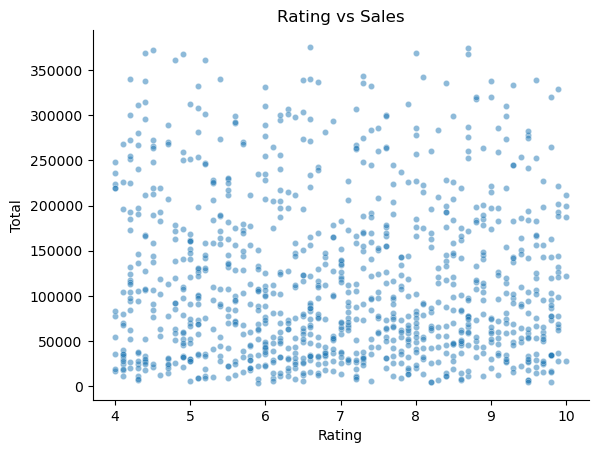

In [330]:
sb.scatterplot(data=combined_df, x='Rating', y='Total', alpha=0.5, s=20)
plt.title('Rating vs Sales')
sb.despine()
plt.savefig('Rating vs Sales.png')
plt.show()

There is no obvious linear relationship between customer rating and sales made

# Advanced Analysis Challenge

In [341]:
# Identify the highest-value customer segments using combinations of branch, gender, and customer type

# First, I need to get my Revenue
combined_df['Revenue'] = combined_df['Quantity'] * combined_df['Unit price']

# Customer segment analysis
segment_analysis = (
    combined_df.groupby(['Branch', 'Gender', 'Customer type'])
    .agg(
        Total_Revenue=('Revenue', 'sum'),
        Average_Order_Value=('Revenue', 'mean'),
        Total_Quantity=('Quantity', 'sum'),
        Transaction_Count=('Revenue', 'count'),
    )
    .reset_index()
)

# Highest-value customer segments
highest_value_customer_segments = segment_analysis.sort_values(
    by='Total_Revenue', ascending=False
)
print(highest_value_customer_segments)

           Branch  Gender Customer type  Total_Revenue  Average_Order_Value  \
8   port harcourt  Female        Member     11881180.8        123762.300000   
9   port harcourt  Female        Normal      9268120.8        113025.863415   
6           lagos    Male        Member      9255225.6        106381.903448   
2           abuja    Male        Member      9207172.8        115089.660000   
0           abuja  Female        Member      9205862.4        108304.263529   
11  port harcourt    Male        Normal      9138996.0        118688.259740   
4           lagos  Female        Member      9134766.0        114184.575000   
5           lagos  Female        Normal      9128948.4        112703.066667   
3           abuja    Male        Normal      9056613.6        100629.040000   
1           abuja  Female        Normal      8940981.6        116116.644156   
7           lagos    Male        Normal      8892615.6         96658.865217   
10  port harcourt    Male        Member      7620973

Based on the ouput above, the highest-value customer segement is FEMALE MEMBERS in PORT HARCOURT, generating 1,188,118 in Total Revenue(96 transactions, 548 units bought)

In [347]:
# Determine whether the product line with the highest quantity sold is also the product line generating the highest value

product_line_analysis = (
    combined_df.groupby('Product line')
    .agg(Total_Quantity=('Quantity', 'sum'), Total_Revenue=('Revenue', 'sum'))
    .reset_index()
)

top_quantity_product_line = product_line_analysis.sort_values(
    by='Total_Quantity', ascending=False
).iloc[0]['Product line']

top_revenue_product_line = product_line_analysis.sort_values(
    by='Total_Revenue', ascending=False
).iloc[0]['Product line']


print(F'Top by Quantity: {top_quantity_product_line}')
print(F'Top by Value: {top_revenue_product_line}\n')

if top_quantity_product_line == top_revenue_product_line:
    print('YES, The top quantity product line is also the highest value generator.')
else:
    print('NO, High quantity does not match high value for this product line.')

Top by Quantity: Electronic accessories
Top by Value: Food and beverages

NO, High quantity does not match high value for this product line.


In [351]:
# Compare weekday and weekend sales patterns

sales_patterns = (
    combined_df.groupby('Day_Type')
    .agg(
        Total_Revenue=('Revenue', 'sum'),
        Average_Revenue_Per_Sale=('Revenue', 'mean'),
        Total_Quantity=('Quantity', 'sum'),
        Total_Transactions=('Revenue', 'count'),
    )
    .reset_index()
)
print(sales_patterns)

  Day_Type  Total_Revenue  Average_Revenue_Per_Sale  Total_Quantity  \
0  Weekday     76247330.4             108459.929445            3813   
1  Weekend     34484126.4             116108.169697            1697   

   Total_Transactions  
0                 703  
1                 297  


WEEKENDS generate a higher Average Revenue Per Sale(116,108.17) than WEEKDAYS(108,459.93), even though WEEKDAYS bring in more revenue due to a longer time frame

In [356]:
# INVESTIGATE WHETHER PEAK SHOPPING HOURS DIFFER BY BRANCH

hourly_branch_sales = (
    combined_df.groupby(['Branch', 'Hour'])
    .size()
    .reset_index(name='Transaction_Count')
)

peak_shopping_hours = hourly_branch_sales[
    hourly_branch_sales['Transaction_Count']
    == hourly_branch_sales.groupby('Branch')['Transaction_Count'].transform(
        'max'
    )
]

print(peak_shopping_hours)

           Branch  Hour  Transaction_Count
9           abuja    19                 50
11          lagos    10                 38
22  port harcourt    10                 37


Peak shopping hours differ by branch, with a clear difference between the evening activity in ABUJA and the morning activities in LAGOS and PORT HARCOURT

Abuja: Peaks in the evening at 19:00 (7 PM) with 50 transactions.

Lagos: Peaks in the morning at 10:00 (10 AM) with 38 transactions.

Port Harcourt: Peaks in the morning at 10:00 (10 AM) with 37 transactions.

In [358]:
# FORMULATE AND TEST AT LEAST TWO(2) ADDITIONAL HYPOTHESIS THAT COULD HELP MANAGEMENT MAKE BETTER DECISIONS

# 1. If MEMBERS generate a significantly higher AVERAGE REVENUE PER TRANSACTION compared to NORMAL customers

membership_analysis = (
    combined_df.groupby('Customer type')
    .agg(
        Total_Revenue=('Revenue', 'sum'),
        Average_Transaction_Value=('Revenue', 'mean'),
        Total_Transactions=('Revenue', 'count'),
    )
    .reset_index()
)

print(membership_analysis)

  Customer type  Total_Revenue  Average_Transaction_Value  Total_Transactions
0        Member     56305180.8              112385.590419                 501
1        Normal     54426276.0              109070.693387                 499


INSIGHT

MEMBERS spend more per transaction on average than NORMAL customers, but the difference is very narrow(only about 3.04%)

Management should aggressively invest in customer acquisition programs to convert "Normal" shoppers into "Members"


The current benefits (discounts, points, or exclusive access) are not doing enough to incentivize larger basket sizes or more frequent visits. Management should introduce tier-based spending rewards

In [362]:
# 2. ANALYZE IF CUSTOMER DEMAND FOR PRODUCT LINES VARIES SIGNIFICANTLY BY BRANCH, PROVING A ONE-SIZE-FITS-ALL INVENTORY MODEl


branch_product_analysis = (
    combined_df.groupby(['Branch', 'Product line'])['Revenue']
    .sum()
    .reset_index()
)

top_product_per_branch = (
    branch_product_analysis.sort_values(by='Revenue', ascending=False)
    .groupby('Branch')
    .first()
    .reset_index()
)

print(top_product_per_branch)

          Branch        Product line    Revenue
0          abuja   Sports and travel  6853096.8
1          lagos  Home and lifestyle  7685895.6
2  port harcourt  Food and beverages  8148636.0


Product line preferences differ significantly by branch, proving that a one-size-fits-all inventory model would fail to capture regional demand.
1. Branch Product Line Breakdown

a. Abuja: Sports and travel is the #1 performer, generating 685,309.68 in revenue.

b. Lagos: Home and lifestyle is the #1 performer, generating 768,595.60 in revenue.

c. Port Harcourt: Food and beverages is the #1 performer, generating 814,863.60 in revenue.




## KEY FINDINGS
1. Port Harcourt has the highest number of sales among the three(3) branches, while Abuja recorded the lowest in 3 months of business(JAN, FEB, MARCH- 2019)
2. Port Harcourt generated the highest gross income among the three(3) branches in 3 months of business(JAN, FEB, MARCH- 2019)
3. January recorded the highest combined revenue generation across all branches, while February experienced a noticeable dip
4. FOOD & BEVERAGES brings in the highest total revenue among the product line, driven by high volume & strong pricing. ELECTRONICS ACCESSORIES sold the highest quantity, though ranked 3rd in total revenue due to having a slightly lower average item value. HEALTH & BEAUTY lags in both revenue and sales
5. Customers with a 'MEMBER' status generated more revenue than 'NORMAL' customers. The difference is relatively small, which suggests that while membership programs are driving the highest portion of sales, Normal customers still make up a massive, nearly equal share of the total revenue
6. While both genders contribute significantly, FEMALE CONSUMERS represent the largest revenue-generating segment(8% difference). This indicates that the product/service holds strong, broad appeal across both genders rather than being niche
7. Epay is the most frequently used payment option overall, accounting for 34.5% of transactions. Epay leads Cash by only a single invoice. Card payment lags slightly behind other methods(31.1%)
8. ABUJA BRANCH prefers Epay(113 transactions), closely followed by Cash (110 transactions) and Card(109 transactions), which shows that distriution is highly balanced(or consumers have no strong single preference). LAGOS BRANCH prefers Epay(126 transactions). PORT HARCOURT BRANCH prefers Cash(124 transactions)
9. A significant portion of Lagos and Port Harcourt customers leave higher rating scores, while customers at the Abuja branch are generally satisfied. The spread & variance of customers' opinions are uniform across all branches.
10. Busiest shopping hours for each branch include: ABUJA(Hour 19 with 50 transactions), LAGOS(Hour 10  with 38 transactions), PORT HARCOURT(Hour 10  with 37 transactions)
11. There is no obvious linear relationship between customer ratings & Sales made.
    
## KEY FINDINGS (ADVANCED ANALYSIS)
1. The highest-value customer segment is FEMALE MEMBERS IN PORT HARCOURT, generating 1,188,118 in total revenue(96 transactions, 548 quantities bought)
2. The product line with the highest quantity sold is not the same as the product line generating the highest value(Top by Quantity- ELECTRONICS ACCESSORIES, Top by Value- FOOD & BEVERAGES)
3. Weekends generate a higher average revenue per sale (116,108.17) than weekdays(108,459.93), even though weekdays bring in more revenue due to a longer time frame
4. Peak shopping hours differ by branch, with a clear difference between the evening activity in ABUJA and morning activities in LAGOS and PORT HARCOURT
5. MEMBERS spend more per transaction on average than NORMAL customers, but the difference is very narrow(only about 3.04%)
6. Product line preferences differ significantly by branch, proving that a one-size-fits-all inventory model would fail to capture regional demand.

## BUSINESS RECOMMENDATIONS
Based on key findings section of the data analysis report, here are the strategic recommendations to optimize sales, marketing, and operations across Castro supermarket branches

  1. Boost Underperforming Branches & Months

   Replicate Success in Abuja: Port Harcourt leads in sales volume, while Abuja recorded the lowest sales volume. Investigate Port Harcourt’s local promotions or inventory management and apply those successful tactics to the Abuja branch.
   
   Targeted February Promotions: Since sales took a noticeable dip in February after peaking in January, plan targeted marketing campaigns, loyalty rewards, or Valentine's Day specific bundles to counteract the post-holiday slump.

  2. Tailor Strategies by Product Category

   Bundle High-Volume with High-Revenue: Food & Beverages brings in the highest total revenue due to high volume, but Health & Beauty lags in both revenue and sales quantity. Create cross-promotional bundles (e.g., "Buy certain grocery items, get a discount on beauty/wellness products") to expose grocery shoppers to the beauty aisle.
   
   Optimize Electronics Inventory: Electronics & Accessories generates high revenue because of its high price point. Maintain strict inventory control over these high-ticket items to ensure high-demand models are always in stock without over-investing in slow-moving stock.

  3. Leverage Customer Demographics & Loyalty

   Convert Normal Customers to Members: Customers with a "Member" status generate more revenue than "Normal" customers, though the gap is currently small. Introduce tiered membership perks or a sign-up discount to incentivize "Normal" customers to register, driving up their lifetime value.

   Expand Female-Targeted Marketing: While both genders contribute significantly, Female consumers represent the largest revenue-generating segment. Allocate a portion of the marketing budget toward campaigns, brands, or product lines that specifically appeal to this demographic.

  4. Optimize Payment and Branch Operations

   Promote Digital Payment Incentives: Epay is the most popular payment method, but Card payments lag slightly behind Cash. Partner with banks or payment gateways to offer cashback or small discounts for card/digital payments to reduce the security risks and processing times associated with handling large amounts of physical cash.
   
   Staffing According to Peak Hours: The data explicitly identifies the busiest shopping hours for each branch:Abuja: Peak hour is 19:00 (7 PM). Lagos: Peak hour is 10:00 AM. Port Harcourt: Peak hour is 10:00 AM. Adjust employee shift schedules so that more cashiers and floor staff are working during these specific windows to improve customer service and reduce checkout wait times.

   KEY FINDINGS (ADVANCED ANALYSIS)

  1. Supply Chain & Inventory Optimization

     Localized Inventory Models: Avoid a "one-size-fits-all" model. Tailor branch inventory based on local preferences rather than uniform stocking across all regions.

     Category-Specific Restocking: Prioritize high-volume inventory like Electronics Accessories to maintain high turnover rates, while ensuring robust supply chains for high-value segments like Food & Beverages.

  3. Tailored Marketing & Branch Operations

     Targeted Regional Promotions: Design unique campaigns for each branch. For example, run evening promotions in the Abuja branch to leverage its late peak activity, and launch early-bird or morning campaigns in Lagos and Port Harcourt.


     Dynamic Branch Staffing: Align staff shifts with specific branch peak hours to improve customer service and manage traffic: Abuja: Increase staffing around Hour 19 (7:00 PM).Lagos & Port Harcourt: Deploy maximum front-end staff around Hour 10 (10:00 AM).

  4. Customer Retention & Revenue Maximization

     VIP Experience for High-Value Segments: Create a tailored loyalty sub-tier or targeted perks specifically designed for Female Members in Port Harcourt to sustain and grow their high-value revenue contributions.

     Weekend Revenue Drivers: Capitalize on higher weekend average sales by introducing bundle deals, family packages, or limited-time weekend discounts to maximize transaction values when spending propensity is highest.

     Member Loyalty Upselling: Since Members outspend Normal customers by roughly 3.04%, launch a conversion campaign at checkout. Offer instant rewards to incentivize "Normal" shoppers to sign up for membership.

# LIMITATIONS
While comprehensive for basic sales tracking, this dataset has several key limitations:

No Unique Customer IDs: Without tracking specific individual customers over time (only broad types like "Member" or "Normal"), you cannot calculate Customer Lifetime Value (CLV), churn rates, or retention metrics.

Lack of Marketing Data: There are no columns tracking promotions, discounts, or ad campaigns. You cannot determine why a customer bought an item or if a specific marketing campaign drove the sale.

No Inventory or Stock Levels: The data shows what was sold, but not what is currently in stock. You cannot use it to manage supply chains or identify out-of-stock issues.

Missing Cost and Operational Details: While it tracks the Cost of Goods Sold (cogs), it ignores overhead costs like rent, employee wages, and utilities, meaning you cannot calculate true net profit.

No Behavioral Context: It lacks feedback text or specific reasons behind low satisfaction ratings (Rating), limiting your ability to perform deep sentiment analysis.


# CONCLUSION
In conclusion, this data-driven analysis provides an actionable framework to transform Castro Supermarket from a uniform model into a highly optimized, localized retail network. Acknowledging data limitations—such as the lack of unique customer tracking—the findings clearly demonstrate that maximizing long-term profitability requires addressing regional variances in demographics, peak hours, and product demand. By systematically deploying tailored inventory models, dynamic branch-specific staffing, and targeted customer loyalty incentives, the business can effectively eliminate operational inefficiencies, mitigate seasonal slumps, and secure sustainable market leadership.


# Here is the additional data the company should consider collecting, grouped by category in order to improve future analysis

1. Customer Insights & Behavior:

   Customer ID / Loyalty Program Number: Tracks individual repeat purchase patterns over time.

   Age/Birthdate: Enables age-based demographic segmentation and birthday promotions.

   Customer Feedback Text: Provides qualitative context behind the numerical Rating.

   Purchase Channel: Tracks if the purchase was made in-store, online, or via a mobile app.

2. Product & Inventory Details:
   Stock Keeping Unit (SKU): Identifies the exact specific item sold, not just the general Product line.

   Inventory Levels: Tracks stockouts to analyze lost sales opportunities.

   Supplier Cost Details: Breaks down cogs into shipping, manufacturing, and storage costs.

3. Marketing & Promotions:

   Discounts & Coupon Codes: Evaluates the effectiveness and ROI of specific promotional campaigns.

   Customer Acquisition Source: Identifies how the customer found the store (e.g., social media, local ad).

4. Operational Factor:

   Staff ID / Cashier ID: Analyzes checkout efficiency and individual employee sales performance.
   